**1. Setup**

In [1]:
%pip install numpy pandas matplotlib seaborn scikit-learn -q


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

**2. Load Data**

In [3]:
df = pd.read_csv("breast_cancer_dataset.csv")

In [4]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
df.shape

(569, 32)

In [6]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='str')

**3. Basic cleanup**

In [7]:
# drop missing values if any
df = df.dropna()

In [8]:
df["diagnosis"].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [9]:
# encode target column
df["diagnosis"] = df["diagnosis"].map({"B": 0, "M": 1})

In [10]:
df["diagnosis"].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

**4. Split features and target**

In [11]:
X = df.drop(columns=["id", "diagnosis"])
y = df["diagnosis"]

In [12]:
X[:5]

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [13]:
y[:5]

0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64

**5. Keep only numeric columns (PCA needs numeric)**

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    int64  
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [15]:
# selecting only numeric columns (can be useful for other dataset. can add categorical columns later after processing)
X = X.select_dtypes(include=[np.number])

In [16]:
X.columns

Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='str')

**6. Train Test Split**

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [18]:
print(X.shape)
print(X_train.shape)
print(X_test.shape)

(569, 30)
(455, 30)
(114, 30)


**7. Standardize features (Important for PCA)**

In [19]:
scaler = StandardScaler()

In [20]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Principal Component Analysis (PCA)**

**8. Fit PCA (start with full components to see explained variance)**

In [21]:
pca_full = PCA()

In [22]:
X_train_pca_full = pca_full.fit_transform(X_train_scaled)

In [23]:
X_train_scaled.shape

(455, 30)

In [24]:
explained_var = pca_full.explained_variance_ratio_
# cumulative explained variance
cum_explained = np.cumsum(explained_var)

In [25]:
print("Explained Variance ratio (first 10):", explained_var[:10])
print("\n")
print("Cumulative Explained Variance (first 10):", cum_explained[:10])

Explained Variance ratio (first 10): [0.44593522 0.18545255 0.09584641 0.06593768 0.05622286 0.03988488
 0.02214493 0.01614006 0.01284789 0.01165661]


Cumulative Explained Variance (first 10): [0.44593522 0.63138778 0.72723419 0.79317187 0.84939473 0.88927961
 0.91142454 0.9275646  0.94041249 0.9520691 ]


**9. plot Cumulative explained variance**

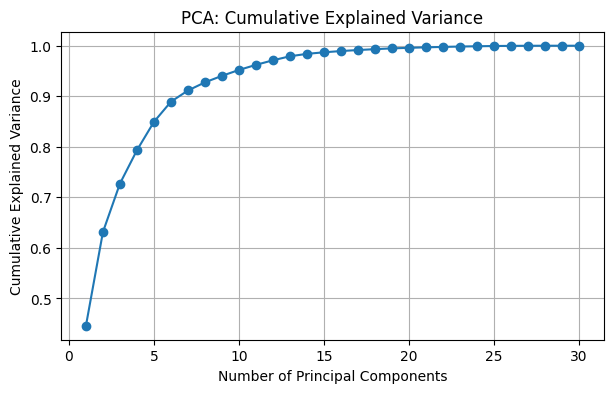

In [26]:
plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(cum_explained) + 1), cum_explained, marker="o")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA: Cumulative Explained Variance")
plt.grid(True)
plt.show()

In [27]:
np.arange(1, len(cum_explained) + 1)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30])

**Choose number of components (example: keep 95% variance)**

In [28]:
n_components_95 = np.argmax(cum_explained >= 0.95) + 1
print("Components to reach 95% variance:", n_components_95)

Components to reach 95% variance: 10


**10. Fit PCA with chosen number of components**

In [29]:
pca = PCA(n_components=n_components_95)

In [30]:
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [31]:
X_train_pca.shape

(455, 10)

In [33]:
X_train_pca[:1]

array([[-0.87593746, -2.57130887, -0.54851057,  1.6357934 , -0.26283591,
         0.10981867,  0.50641431, -0.21445967, -0.10938357,  0.41669486]])

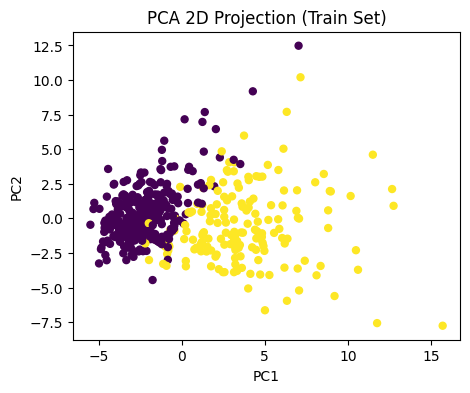

In [34]:
# 12) 2D PCA scatter plot (only if target exists)
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_train_scaled)

plt.figure(figsize=(5,4))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_train, s=25)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D Projection (Train Set)")
plt.show()

**11. Model performance comparison before vs after pca**

In [35]:
# Model BEFORE PCA (on scaled original features)
model_before = LogisticRegression()
model_before.fit(X_train_scaled, y_train)
pred_before = model_before.predict(X_test_scaled)
acc_before = accuracy_score(y_test, pred_before)

# Model AFTER PCA
model_after = LogisticRegression()
model_after.fit(X_train_pca, y_train)
pred_after = model_after.predict(X_test_pca)
acc_after = accuracy_score(y_test, pred_after)

print("\n===== Model Comparison (Logistic Regression) =====")
print("Accuracy BEFORE PCA:", round(acc_before, 4))
print("Accuracy AFTER  PCA :", round(acc_after, 4))

print("\nClassification report (BEFORE PCA):")
print(classification_report(y_test, pred_before))

print("\nClassification report (AFTER PCA):")
print(classification_report(y_test, pred_after))



===== Model Comparison (Logistic Regression) =====
Accuracy BEFORE PCA: 0.9649
Accuracy AFTER  PCA : 0.9737

Classification report (BEFORE PCA):
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


Classification report (AFTER PCA):
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

